In [1]:
# Week 3 Day 3: ROC Curve and ROC-AUC

## Today's Goal

Today I will learn how to evaluate a binary classifier across different classification threholds using the ROC curve and ROC-AUC.

## Learning Objectives

- Reveiw prediction probabilities and classification thresholds
- Understand True Positive Rate (TPR)
- Understand False Positive Rate (FPR)
- Understand how changing the thresholds changes model behavior
- Plot and interpret an ROC curve
- Understand the basic intuition of ROC-AUC

## Expected Output

By the end of today, I should be able to:

1. Explain how a classification threhold converts probabilities into class predictions
2. Explain TPR and FPR
3. Interpret the main meaning of an ROC curve
4. Explain what a higher ROC-AUC generally means
5. Distinguish ROC-AUC from accuracy

SyntaxError: invalid syntax (666093470.py, line 5)

In [2]:
## Setup: Recreate the Day 2 Model
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Recreate the same imbalanced dataset from Day 2
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.95, 0.05],
    random_state=42
)

# Same train/test split as Day 2
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Recreate the normal Logistic Regression pipeline
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(random_state=42))
])

# Train the model
logreg_pipeline.fit(X_train, y_train)

print("Model recreated successfully.")
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Model recreated successfully.
Training shape: (800, 10)
Test shape: (200, 10)


In [3]:
## Prediction Probabilities and Threholds 
# Probability of belonging to Class 1
y_prob = logreg_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_prob[:10])

print("\nMinimum probability:", y_prob.min())
print("Maximum proability:", y_prob.max())

First 10 predicted probabilities:
[0.0551241  0.04475389 0.02551601 0.02664466 0.05803656 0.03393491
 0.0337249  0.01530756 0.01134058 0.21603377]

Minimum probability: 0.0022474710444222576
Maximum proability: 0.7354792219004954


In [4]:
## Comparing Different Classification Thresholds
from sklearn.metrics import confusion_matrix

# Thresholds we want to compare
thresholds = [0.2, 0.5, 0.8]

for threshold in thresholds:
    
    # Convert probabilities into class predictions
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    # Get confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()
    
    # Calculate TPR and FPR
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    
    print(f"Threshold = {threshold}")
    print(f"TP = {tp}, FN = {fn}, FP = {fp}, TN = {tn}")
    print(f"TPR = {tpr:.3f}")
    print(f"FPR = {fpr:.3f}")
    print("-" * 40)

Threshold = 0.2
TP = 6, FN = 5, FP = 7, TN = 182
TPR = 0.545
FPR = 0.037
----------------------------------------
Threshold = 0.5
TP = 1, FN = 10, FP = 0, TN = 189
TPR = 0.091
FPR = 0.000
----------------------------------------
Threshold = 0.8
TP = 0, FN = 11, FP = 0, TN = 189
TPR = 0.000
FPR = 0.000
----------------------------------------


In [6]:
## Compared Different Classification Thresholds
from sklearn.metrics import confusion_matrix

# Thresholds we want to compare
thresholds = [0.2, 0.5, 0.8]

for threshold in thresholds:

    # Convert probabilities into class predictions
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Get confusion matrix
    tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_threshold
    ).ravel()

    # Calculate TPR and FPR
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    print(f"Threshold = {threshold}")
    print(f"TP = {tp}, FN {fn}, FP = {fp}, TN = {tn}")
    print(f"TPR = {tpr:.3f}")
    print(f"FPR = {fpr:.3f}")
    print("-" * 40)

Threshold = 0.2
TP = 6, FN 5, FP = 7, TN = 182
TPR = 0.545
FPR = 0.037
----------------------------------------
Threshold = 0.5
TP = 1, FN 10, FP = 0, TN = 189
TPR = 0.091
FPR = 0.000
----------------------------------------
Threshold = 0.8
TP = 0, FN 11, FP = 0, TN = 189
TPR = 0.000
FPR = 0.000
----------------------------------------


In [ ]:
## ROC Curve and ROC-AUC
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)
print("Number of ROC points:", len(fpr))

# Plot ROC curve
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ROC-AUC: 0.9004329004329005
Number of ROC points: 15


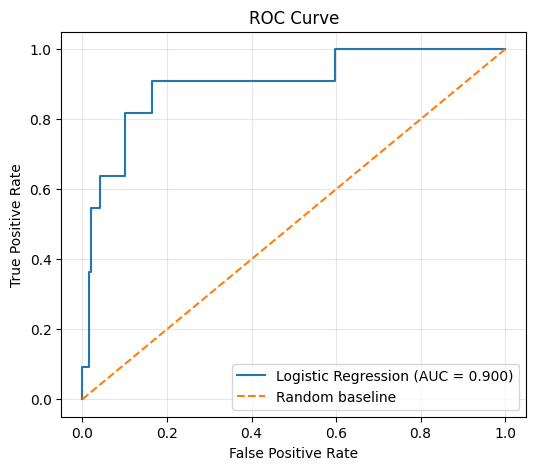

In [8]:
## ROC Curve and ROC-AUC
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)
print("Number of ROC points:", len(fpr))

# Plot ROC curve
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Reflection

1. What is the main difference between accuracy and ROC-AUC?
Accuracy evaluates classification decisions at a particular threshold and ROC-AUC summarizes ranking quality.
2. Why can a model have poor recall at threshold 0.5 but still have a high ROC-AUC?
ROC-AUC shows the ability of ranking positive samples above nagetive samples. Recall = TP / TP + FN. With a high ROC-AUC, the model can
better rank one positive sample above nagetive sample but the probability of the positive sample is less than threshold which likely cause
recall is still low 
3. Why does ROC-AUC not automatically tell us which classification threshold to use?
ROC-AUC shows the ability of ranking positive ssamples above nagetive samples which does not change with different thresholds in a certain 
model